# New Ways Game — Prototype

A figure moves from **bottom-left** to **top-right** on an N×N board.  
Each step is one field: **U / D / L / R**.  
**Rule:** after every move, `find_repeat_seq` applied to the whole move-sequence must return `None`.

## 1 — Core constraint: `find_repeat_seq`

In [5]:
def find_repeat_seq(s: str) -> str | None:
    """
    Returns the shortest unit U such that U repeated at least twice consecutively
    appears anywhere as a substring of s, or None.
    Examples: 'aa'->'a', 'abab'->'ab', 'xaax'->'a', 'xababx'->'ab', 'abcd'->None
    """
    n = len(s)
    for unit_len in range(1, n // 2 + 1):
        for start in range(n - 2 * unit_len + 1):
            unit = s[start:start + unit_len]
            if s[start + unit_len:start + 2 * unit_len] == unit:
                return unit
    return None


# Quick sanity check
cases = [
    # prefix repeats (unchanged behaviour)
    ('aa', 'a'), ('abab', 'ab'), ('abcabc', 'abc'), ('ababab', 'ab'),
    ('abcd', None), ('a', None), ('aaaaaa', 'a'), ('abcabcabc', 'abc'),
    # non-prefix repeats (new behaviour)
    ('xaax', 'a'), ('xababx', 'ab'), ('abcbcx', 'bc'), ('abcdabcbc', 'bc'),
]
for s, expected in cases:
    got = find_repeat_seq(s)
    mark = '✓' if got == expected else '✗'
    print(f"{mark}  find_repeat_seq({s!r:14}) = {str(got):8}  expected {expected}")

✓  find_repeat_seq('aa'          ) = a         expected a
✓  find_repeat_seq('abab'        ) = ab        expected ab
✓  find_repeat_seq('abcabc'      ) = abc       expected abc
✓  find_repeat_seq('ababab'      ) = ab        expected ab
✓  find_repeat_seq('abcd'        ) = None      expected None
✓  find_repeat_seq('a'           ) = None      expected None
✓  find_repeat_seq('aaaaaa'      ) = a         expected a
✓  find_repeat_seq('abcabcabc'   ) = abc       expected abc
✓  find_repeat_seq('xaax'        ) = a         expected a
✓  find_repeat_seq('xababx'      ) = ab        expected ab
✓  find_repeat_seq('abcbcx'      ) = bc        expected bc
✓  find_repeat_seq('abcdabcbc'   ) = bc        expected bc


## 2 — Game class

In [6]:
MOVE_DELTA = {'U': (0, 1), 'D': (0, -1), 'L': (-1, 0), 'R': (1, 0)}

class Game:
    """
    Board is N×N. Origin (0,0) = bottom-left. Target = (N-1, N-1) = top-right.
    Coordinates: (col, row), row increases upward.
    """
    def __init__(self, size: int = 8):
        self.size = size
        self.reset()

    def reset(self):
        self.col, self.row = 0, 0
        self.seq = ''
        self.history = [(0, 0)]
        self.won = False

    @property
    def pos(self):
        return (self.col, self.row)

    @property
    def target(self):
        return (self.size - 1, self.size - 1)

    def valid_moves(self) -> list[str]:
        result = []
        for m, (dc, dr) in MOVE_DELTA.items():
            nc, nr = self.col + dc, self.row + dr
            if 0 <= nc < self.size and 0 <= nr < self.size:
                if find_repeat_seq(self.seq + m) is None:
                    result.append(m)
        return result

    def move(self, m: str) -> tuple[bool, str]:
        dc, dr = MOVE_DELTA[m]
        nc, nr = self.col + dc, self.row + dr
        if not (0 <= nc < self.size and 0 <= nr < self.size):
            return False, 'out of bounds'
        new_seq = self.seq + m
        rep = find_repeat_seq(new_seq)
        if rep is not None:
            return False, f'sequence "{new_seq}" repeats "{rep}"'
        self.col, self.row = nc, nr
        self.seq = new_seq
        self.history.append(self.pos)
        if self.pos == self.target:
            self.won = True
        return True, 'ok'

    def undo(self) -> bool:
        if not self.seq:
            return False
        self.seq = self.seq[:-1]
        self.history.pop()
        self.col, self.row = self.history[-1]
        self.won = False
        return True

    def status(self) -> str:
        if self.won:
            return f'★ WON! ({len(self.seq)} moves)  seq: {self.seq}'
        valid = self.valid_moves()
        if not valid:
            return f'✗ Stuck (no valid moves)  seq: {self.seq or "(none)"}'
        return (f'pos ({self.col},{self.row})  moves: {len(self.seq)}  '
                f'seq: {self.seq or "(none)"}  valid next: {valid}')


# Demo
g = Game(3)
for m in ['R', 'U', 'U', 'R']:
    ok, msg = g.move(m)
    print(f'move {m}: {msg:6}  →  {g.status()}')

move R: ok      →  pos (1,0)  moves: 1  seq: R  valid next: ['U', 'L']
move U: ok      →  pos (1,1)  moves: 2  seq: RU  valid next: ['D', 'L', 'R']
move U: sequence "RUU" repeats "U"  →  pos (1,1)  moves: 2  seq: RU  valid next: ['D', 'L', 'R']
move R: ok      →  pos (2,1)  moves: 3  seq: RUR  valid next: ['D', 'L']


## 3 — Board visualization

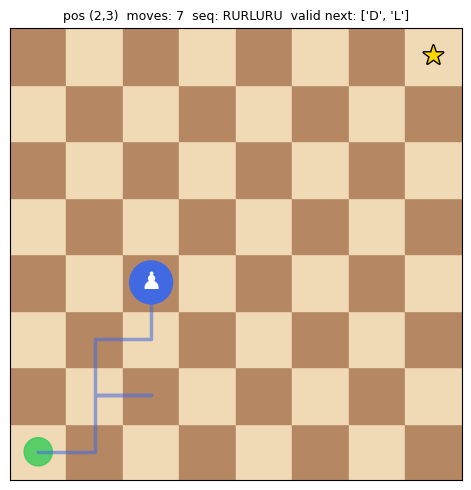

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def draw_board(game: Game, ax=None, title: str = '') -> plt.Axes:
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    n = game.size
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(-0.5, n - 0.5)
    ax.set_aspect('equal')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # Checkerboard squares
    for c in range(n):
        for r in range(n):
            color = '#f0d9b5' if (c + r) % 2 == 0 else '#b58863'
            ax.add_patch(patches.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                           color=color, zorder=0))

    # Start (green) and target (gold star)
    ax.add_patch(patches.Circle((0, 0), 0.25, color='#33cc55', alpha=0.8, zorder=1))
    ax.text(n - 1, n - 1, '★', ha='center', va='center',
            fontsize=18, color='gold', zorder=2,
            fontweight='bold', path_effects=[
                __import__('matplotlib.patheffects', fromlist=['withStroke'])
                .withStroke(linewidth=2, foreground='black')])

    # Path trail
    if len(game.history) > 1:
        hist = np.array(game.history, dtype=float)
        ax.plot(hist[:, 0], hist[:, 1], '-',
                color='royalblue', linewidth=2.5, alpha=0.55, zorder=2)

    # Current piece
    ax.add_patch(patches.Circle((game.col, game.row), 0.38,
                                color='royalblue', zorder=3))
    ax.text(game.col, game.row, '♟', ha='center', va='center',
            fontsize=17, color='white', zorder=4)

    if title:
        ax.set_title(title, fontsize=9, pad=6)
    return ax


# Preview
g = Game(8)
for m in ['R','U','R','U','L','U','R','U','R','U']:
    g.move(m)
fig, ax = plt.subplots(figsize=(5, 5))
draw_board(g, ax, title=g.status())
plt.tight_layout()
plt.show()

## 4 — Interactive play (ipywidgets)

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def interactive_game(size: int = 8):
    game = Game(size)
    out = widgets.Output()

    def render():
        with out:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(5.5, 5.5))
            draw_board(game, ax)
            ax.set_title(game.status(), fontsize=9, wrap=True)
            plt.tight_layout()
            plt.show()
            valid = game.valid_moves()
            print('Valid moves:', valid if valid else 'NONE — stuck!')

    def make_handler(m):
        def handler(b):
            ok, msg = game.move(m)
            if not ok:
                print(f'  ✗ {m} blocked: {msg}')
            render()
        return handler

    W = widgets.Layout(width='64px', height='48px')
    btn_u     = widgets.Button(description='▲ U', layout=W)
    btn_d     = widgets.Button(description='▼ D', layout=W)
    btn_l     = widgets.Button(description='◄ L', layout=W)
    btn_r     = widgets.Button(description='► R', layout=W)
    btn_undo  = widgets.Button(description='Undo',  button_style='warning',
                               layout=widgets.Layout(width='64px'))
    btn_reset = widgets.Button(description='Reset', button_style='danger',
                               layout=widgets.Layout(width='64px'))

    for m, btn in [('U', btn_u), ('D', btn_d), ('L', btn_l), ('R', btn_r)]:
        btn.on_click(make_handler(m))

    def on_undo(b):  game.undo();  render()
    def on_reset(b): game.reset(); render()
    btn_undo.on_click(on_undo)
    btn_reset.on_click(on_reset)

    pad = widgets.Layout(width='64px', height='48px', visibility='hidden')
    controls = widgets.VBox([
        widgets.HBox([widgets.Box(layout=pad), btn_u,    widgets.Box(layout=pad)]),
        widgets.HBox([btn_l,                   btn_d,    btn_r]),
        widgets.HBox([btn_undo,                btn_reset]),
    ])
    display(widgets.HBox([out, controls]))
    render()


interactive_game(size=8)

## 7 — Random simulation

In [7]:
import random

def _filter_blocked(moves: list[str], col: int, row: int,
                    blocked: frozenset) -> list[str]:
    """Remove moves that would land on a blocked cell."""
    return [m for m in moves
            if (col + MOVE_DELTA[m][0], row + MOVE_DELTA[m][1]) not in blocked]


def random_game(size: int = 8, seed: int | None = None,
                blocked: set | frozenset | None = None) -> dict:
    """
    Plays random valid moves until stuck or won.
    blocked: optional set of (col, row) cells the figure cannot enter.
    Returns a dict with outcome info.
    """
    if seed is not None:
        random.seed(seed)
    bl = frozenset(blocked or [])
    g = Game(size)
    while True:
        valid = _filter_blocked(g.valid_moves(), g.col, g.row, bl)
        if not valid or g.won:
            break
        g.move(random.choice(valid))
    return {'won': g.won, 'steps': len(g.seq), 'seq': g.seq, 'final_pos': g.pos}


def simulate(size: int = 8, n_runs: int = 500, seed: int = 42,
             blocked: set | frozenset | None = None) -> None:
    label = f'blocked={sorted(blocked)}' if blocked else 'no blocked cells'
    random.seed(seed)
    results = [random_game(size, blocked=blocked) for _ in range(n_runs)]
    wins   = [r for r in results if r['won']]
    losses = [r for r in results if not r['won']]
    print(f'{size}×{size} board — {n_runs} random games ({label}):')
    print(f'  Won: {len(wins)} ({100*len(wins)/n_runs:.1f}%)')
    if wins:
        lengths = [r['steps'] for r in wins]
        print(f'  Winning path lengths: min={min(lengths)}, max={max(lengths)}, '
              f'avg={sum(lengths)/len(lengths):.1f}')
        print(f'  Shortest win: {min(wins, key=lambda r: r["steps"])["seq"]}')
    if losses:
        dead_lengths = [r['steps'] for r in losses]
        print(f'  Dead-end path avg length: {sum(dead_lengths)/len(dead_lengths):.1f}')


# simulate(size=4, n_runs=2000)
# simulate(size=8, n_runs=2000)


In [21]:
def greedy_game(size: int = 8, seed: int | None = None,
                blocked: set | frozenset | None = None) -> dict:
    """
    Plays until stuck or won.
    Each move: prefer directions that reduce the distance to the goal in at least
    one coordinate (i.e. move toward target along col or row axis).
    Among qualifying moves no preference — pick randomly.
    Fall back to a random valid move if none qualify.
    blocked: optional set of (col, row) cells the figure cannot enter.
    """
    if seed is not None:
        random.seed(seed)
    bl = frozenset(blocked or [])
    g = Game(size)
    tc, tr = g.target
    for _ in range(150):
        valid = _filter_blocked(g.valid_moves(), g.col, g.row, bl)
        if not valid or g.won:
            break
        greedy = [
            m for m in valid
            if (abs(g.col + MOVE_DELTA[m][0] - tc) < abs(g.col - tc))
            or (abs(g.row + MOVE_DELTA[m][1] - tr) < abs(g.row - tr))
        ]
        g.move(random.choice(greedy if greedy else valid))
    return {'won': g.won, 'steps': len(g.seq), 'seq': g.seq, 'final_pos': g.pos}


def simulate_greedy(size: int = 8, n_runs: int = 500, seed: int = 42,
                    blocked: set | frozenset | None = None) -> None:
    label = f'blocked={sorted(blocked)}' if blocked else 'no blocked cells'
    random.seed(seed)
    results = [greedy_game(size, blocked=blocked) for _ in range(n_runs)]
    wins   = [r for r in results if r['won']]
    losses = [r for r in results if not r['won']]
    print(f'{size}×{size} board — {n_runs} greedy games ({label}):')
    print(f'  Won: {len(wins)} ({100*len(wins)/n_runs:.1f}%)')
    if wins:
        lengths = [r['steps'] for r in wins]
        print(f'  Winning path lengths: min={min(lengths)}, max={max(lengths)}, '
              f'avg={sum(lengths)/len(lengths):.1f}')
        print(f'  Shortest win: {min(wins, key=lambda r: r["steps"])["seq"]}')
    if losses:
        dead_lengths = [r['steps'] for r in losses]
        print(f'  Dead-end path avg length: {sum(dead_lengths)/len(dead_lengths):.1f}')


simulate_greedy(size=5, n_runs=2000)
simulate_greedy(size=6, n_runs=2000)
simulate_greedy(size=7, n_runs=2000)
simulate_greedy(size=8, n_runs=2000)


5×5 board — 2000 greedy games (no blocked cells):
  Won: 1962 (98.1%)
  Winning path lengths: min=14, max=32, avg=16.0
  Shortest win: URUDURULRURDUR
  Dead-end path avg length: 17.0
6×6 board — 2000 greedy games (no blocked cells):
  Won: 1972 (98.6%)
  Winning path lengths: min=18, max=40, avg=21.0
  Shortest win: URUDURULRURDURUDRU
  Dead-end path avg length: 22.0
7×7 board — 2000 greedy games (no blocked cells):
  Won: 1760 (88.0%)
  Winning path lengths: min=22, max=44, avg=24.9
  Shortest win: URUDURULRURDURUDRURLUR
  Dead-end path avg length: 18.9
8×8 board — 2000 greedy games (no blocked cells):
  Won: 1639 (82.0%)
  Winning path lengths: min=26, max=48, avg=29.5
  Shortest win: URUDRURDRULURUDURULURUDRUR
  Dead-end path avg length: 18.3


## 8 — Simulation with blocked fields

Define any cells the figure cannot enter as `(col, row)` coordinates, then re-run random and greedy simulations to see how blocking affects win rates and path lengths.

In [ ]:
# ── Define blocked fields here (col, row) ────────────────────────────────────
# These cells act as walls: the figure cannot step onto them.
# (0,0) = bottom-left  |  (N-1, N-1) = top-right (goal)
# Start and goal are never blocked automatically — just don't list them here.

BLOCKED_A = {
    (1, 3),   # middle-ish on a 4×4 board
    (1, 4),
    (2, 3),
    (2, 3),
    (3, 4),
}

BLOCKED_B = {
    (1, 3),   # middle-ish on a 4×4 board
    (1, 4),
    (2, 3),
}

BLOCKED_C = {
    (1, 3),   
    (2, 3),
    (6, 5),
    (5, 5),
}

# ─────────────────────────────────────────────────────────────────────────────

# print('=== 4×4 board ===')
# simulate       (size=4, n_runs=2000, blocked=BLOCKED_A)
# simulate_greedy(size=4, n_runs=2000, blocked=BLOCKED_A)

print()
print('=== 8×8 board ===')
simulate_greedy(size=8, n_runs=2000, blocked=BLOCKED_A)
simulate_greedy(size=8, n_runs=2000, blocked=BLOCKED_B)
simulate_greedy(size=8, n_runs=2000, blocked=BLOCKED_C)



=== 8×8 board ===
8×8 board — 2000 greedy games (blocked=[(1, 3), (1, 4), (2, 3), (3, 4)]):
  Won: 1578 (78.9%)
  Winning path lengths: min=26, max=52, avg=30.8
  Shortest win: RURLRURDURULRURLURUDRURLUR
  Dead-end path avg length: 14.3
8×8 board — 2000 greedy games (blocked=[(1, 3), (1, 4), (2, 3)]):
  Won: 1538 (76.9%)
  Winning path lengths: min=26, max=46, avg=30.9
  Shortest win: URUDRURDURULURUDRURLURUDRU
  Dead-end path avg length: 14.2
8×8 board — 2000 greedy games (blocked=[(1, 3), (2, 3), (5, 5), (6, 5)]):
  Won: 238 (11.9%)
  Winning path lengths: min=26, max=54, avg=34.4
  Shortest win: RURDURULRURLRULURULRURDRUR
  Dead-end path avg length: 25.5
